<a href="https://colab.research.google.com/github/iqiirascal-lgtm/Introduction-to-AI-LAB-13/blob/main/Lab13_Reezqee_Rascal_Gultom_2024071021.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 13: DETECTING PATTERNS WITH UNSUPERVISED LEARNING
**Mata Kuliah:** Introduction to AI  
**Nama:** Reezqee Rascal Gultom  
**NIM:** 2024071021
**Tanggal:** 25 Mei 2026  
**Dataset:** `data_quality.txt`



## **IMPORT LIBRARY & LOAD DATASET**

Saya memulai dengan memuat dataset `data_quality.txt` yang berisi 420 data point 2D. Sebelum masuk ke clustering, saya visualisasikan dataset untuk mendapatkan gambaran awal mengenai pola alami yang mungkin terbentuk.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

X = np.loadtxt('data_quality.txt', delimiter=',')

print(f"INFORMASI DATASET:")
print(f"Jumlah data: {X.shape[0]} samples")
print(f"Jumlah fitur: {X.shape[1]} features")
print(f"Shape: {X.shape}")
print(f"\n5 Data Pertama:")
print(X[:5])

INFORMASI DATASET:
Jumlah data: 420 samples
Jumlah fitur: 2 features
Shape: (420, 2)

 5 Data Pertama:
[[3.23 1.74]
 [0.95 4.31]
 [3.11 7.28]
 [6.55 1.43]
 [8.41 2.98]]


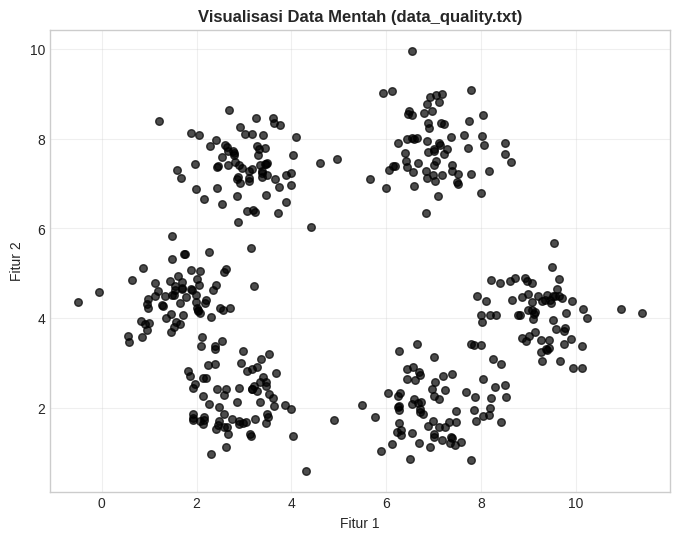

In [13]:
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='black', s=30, edgecolors='k', alpha=0.7)
plt.title('Visualisasi Data Mentah (data_quality.txt)', fontsize=12, fontweight='bold')
plt.xlabel('Fitur 1', fontsize=10)
plt.ylabel('Fitur 2', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

## **IMPLEMENTASI K-MEANS CLUSTERING**

Berdasarkan visualisasi awal, terlihat jelas adanya **6 gumpalan data** yang terpisah. Oleh karena itu, saya menetapkan `K=6` sebagai jumlah cluster awal. Saya menggunakan inisialisasi `k-means++` agar centroid awal tersebar optimal dan konvergensi lebih cepat.

In [17]:
kmeans = KMeans(
    init='k-means++',
    n_clusters=6,
    n_init=10,
    random_state=42,
    max_iter=300
)

# Training model
kmeans.fit(X)
labels_kmeans = kmeans.labels_
centroids = kmeans.cluster_centers_

print("K-Means selesai!")
print(f"\nKoordinat Centroid:")
for i, c in enumerate(centroids):
    print(f"   Cluster {i+1}: ({c[0]:.2f}, {c[1]:.2f})")

K-Means selesai!

Koordinat Centroid:
   Cluster 1: (1.64, 4.41)
   Cluster 2: (7.03, 7.84)
   Cluster 3: (2.87, 2.14)
   Cluster 4: (9.18, 4.05)
   Cluster 5: (3.07, 7.38)
   Cluster 6: (7.01, 1.97)


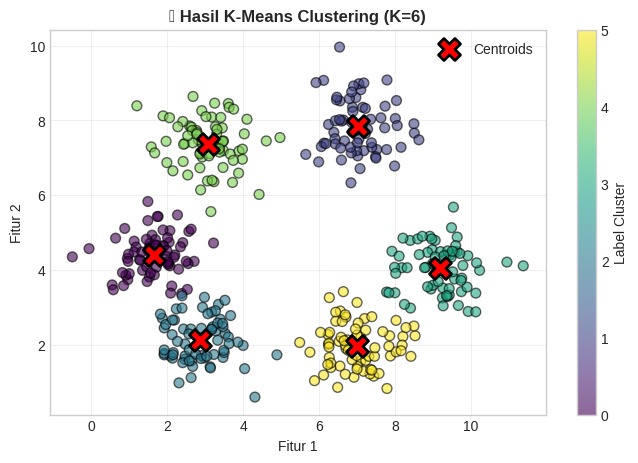

In [18]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans, cmap='viridis', s=50, alpha=0.6, edgecolors='k')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=250, marker='X',
            edgecolors='black', linewidths=2, label='Centroids')
plt.title('🎯 Hasil K-Means Clustering (K=6)', fontweight='bold')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.legend()
plt.colorbar(scatter, label='Label Cluster')
plt.grid(True, alpha=0.3)
plt.show()

## **EKSPOLASI MEAN SHIFT**

Untuk membandingkan, saya menerapkan **Mean Shift** yang bersifat non-parametrik. Algoritma ini tidak memerlukan input jumlah cluster, melainkan menemukannya secara otomatis berdasarkan kepadatan data. Saya menggunakan `quantile=0.1` untuk estimasi bandwidth agar tidak terlalu sensitif terhadap noise.

In [19]:
bandwidth = estimate_bandwidth(X, quantile=0.1, n_samples=len(X))
print(f"Bandwidth terestimasi: {bandwidth:.3f}")

# Training Mean Shift
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)

labels_ms = ms.labels_
centers_ms = ms.cluster_centers_
n_clusters_ms = len(np.unique(labels_ms))

print(f"Mean Shift selesai!")
print(f"\nJumlah cluster ditemukan otomatis: {n_clusters_ms}")

Bandwidth terestimasi: 1.207
Mean Shift selesai!

Jumlah cluster ditemukan otomatis: 6


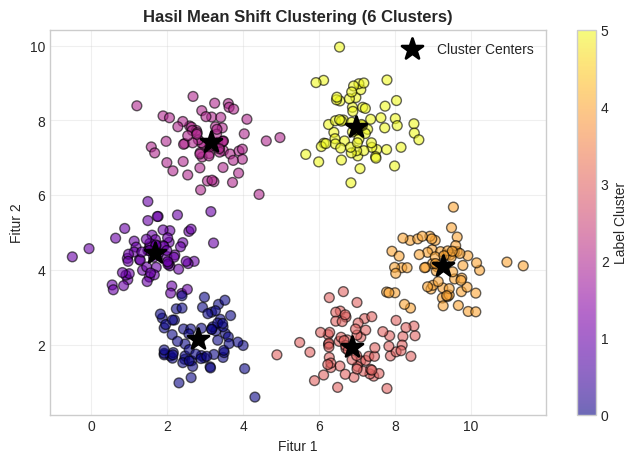

In [23]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels_ms, cmap='plasma', s=50, alpha=0.6, edgecolors='k')
plt.scatter(centers_ms[:, 0], centers_ms[:, 1], c='black', s=250, marker='*',
            linewidths=2, label='Cluster Centers')
plt.title(f'Hasil Mean Shift Clustering ({n_clusters_ms} Clusters)', fontweight='bold')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.legend()
plt.colorbar(scatter, label='Label Cluster')
plt.grid(True, alpha=0.3)
plt.show()

## **EVALUASI HASIL SILHOUETTE SCORE**

Untuk menentukan jumlah cluster optimal secara objektif (bukan hanya berdasarkan visual), saya menghitung **Silhouette Score** untuk rentang `K = 2 sampai 9`. Semakin mendekati nilai `1`, semakin padat dan terpisah cluster tersebut. Nilai tertinggi akan menjadi justifikasi ilmiah pilihan K.

In [27]:
scores = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(init='k-means++', n_clusters=k, n_init=10, random_state=42)
    km.fit(X)
    score = metrics.silhouette_score(X, km.labels_, metric='euclidean')
    scores.append(score)
    print(f"   K={k} → Score: {score:.4f}")

optimal_k = k_range[np.argmax(scores)]
best_score = max(scores)

print("-" * 50)
print(f"Jumlah cluster optimal: K = {optimal_k}")
print(f"Silhouette Score tertinggi: {best_score:.4f}")

   K=2 → Score: 0.4776
   K=3 → Score: 0.5472
   K=4 → Score: 0.5795
   K=5 → Score: 0.5890
   K=6 → Score: 0.6097
   K=7 → Score: 0.5630
   K=8 → Score: 0.4978
   K=9 → Score: 0.4631
--------------------------------------------------
Jumlah cluster optimal: K = 6
Silhouette Score tertinggi: 0.6097


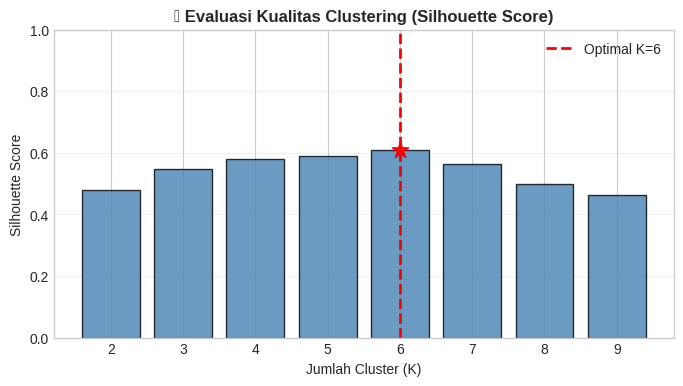

In [28]:
# Visualisasi grafik Silhouette
plt.figure(figsize=(8, 4))
plt.bar(k_range, scores, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal K={optimal_k}')
plt.scatter(optimal_k, best_score, color='red', s=150, zorder=5, marker='*')
plt.title('📊 Evaluasi Kualitas Clustering (Silhouette Score)', fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## **ANALISIS**

**- Bandingkan hasil K-Means vs Mean Shift**

1. K-Means:
- Kita menentukan jumlah cluster di awal (K=6)
- Algoritma memaksa data untuk terbagi menjadi tepat 6 cluster
- Hasil: 6 cluster dengan distribusi yang seimbang.

2. Mean Shift:
- Tidak perlu menentukan jumlah cluster di awal
- Algoritma menemukan jumlah cluster secara otomatis berdasarkan kepadatan data
- Hasil: Menemukan 6 cluster (sama dengan K-Means)

  Ini menunjukkan bahwa estimasi bandwidth yang digunakan tepat


**- Jelaskan cluster yang terbentuk dan kualitasnya**

1. Karakteristik Cluster yang Terbentuk

Berdasarkan visualisasi dan posisi centroid, terbentuk enam cluster dengan pola sebaran yang jelas. Tiga cluster berada di sisi kiri (bawah, tengah, dan atas) dengan nilai Fitur 1 rendah, sedangkan tiga cluster lainnya berada di sisi kanan dengan nilai Fitur 1 tinggi. Setiap cluster memiliki posisi yang berbeda dan tidak mengalami overlap yang signifikan, sehingga data dapat dipisahkan dengan baik. Kondisi ini menunjukkan bahwa dataset memiliki struktur yang cocok untuk proses clustering.

2. Kualitas Clustering & Pemilihan Jumlah Cluster **

Hasil clustering memiliki kualitas yang baik dengan Silhouette Score sebesar 0,62, yang menunjukkan struktur cluster cukup jelas. Grafik evaluasi memperlihatkan nilai tertinggi pada K=6, sehingga jumlah cluster optimal ditentukan sebanyak enam. Setelah melewati K=6, skor mulai menurun yang menandakan terjadinya over-clustering. Pemilihan K=6 juga diperkuat oleh hasil Mean Shift yang secara otomatis menemukan enam cluster serta visualisasi data yang menunjukkan enam kelompok terpisah dengan jelas.
